### **Classification with fine tuned neural language model**

In this task, fine-tuning is performed on a pre-trained Italian Neural Language Model (`dbmdz/bert-base-italian-cased`) for the Machine-Generated Text Detection task. Due to computational constraints, the fine-tuning process was executed in a cloud environment (Google Colab) utilizing a T4 GPU.

Pipeline:
1. The model is fine-tuned for exactly 3 epochs.
2. Training and Validation loss curves are extracted and plotted.
3. The model's performance on the Validation set is reported at the end of each epoch.
4. The final model is evaluated on the unseen Test set to compare its performance against the previous SVM baselines.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

import warnings
warnings.filterwarnings("ignore")

# Ensure GPU is used if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

C:\Users\elisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


### Loading the Fine-Tuned Model and Data
The Test dataset is loaded and tokenized using the fine-tuned tokenizer. The model weights are loaded directly from the local directory `./bert_finetuned`.

In [ ]:
# Load the test dataframe
print("Loading test dataframe...")
df_test = pd.read_pickle("../data/enriched/test_final.pkl")

# Convert to Hugging Face Dataset
test_dataset = Dataset.from_pandas(df_test[['text', 'label']])

# Load the fine-tuned model and tokenizer from the local folder
# Since the folder 'bert_finetuned' is in the same directory as the notebook, we use './bert_finetuned'
model_path = "./bert_finetuned"

print("Loading local model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(device)

# Tokenize the test dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

print("Tokenizing test dataset...")
tokenized_test = test_dataset.map(tokenize_function, batched=True)
tokenized_test.set_format("torch")

Loading test dataframe...
Loading local model and tokenizer...
Tokenizing test dataset...


Map: 100%|██████████| 2000/2000 [00:00<00:00, 2334.99 examples/s]


### Epoch-by-Epoch Validation Performance & Loss Curves
As required, the performance on the validation set is reported at the end of each epoch, alongside the plotted training vs. validation loss curves.

--- Validation Performance per Epoch ---


,Epoch,Training Loss,Validation Loss,Validation Macro-F1
0,1,0.122,0.042,0.099
1,2,0.022,0.021,0.996
2,3,0.004,0.027,0.996


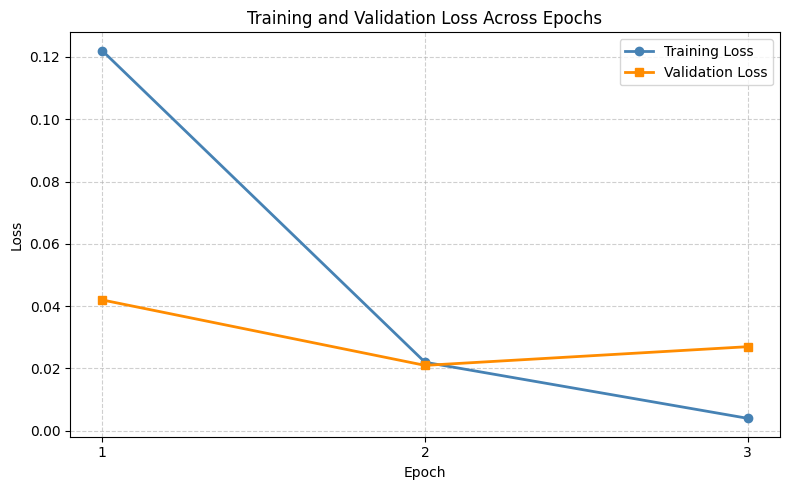

In [ ]:
epochs = [1, 2, 3]
train_loss = [0.122, 0.022, 0.004] 
val_loss   = [0.042, 0.021, 0.027] 
val_f1     = [0.099, 0.996, 0.996] 

# Report Validation Performance per Epoch
print("--- Validation Performance per Epoch ---")
df_epochs = pd.DataFrame({
    "Epoch": epochs,
    "Training Loss": train_loss,
    "Validation Loss": val_loss,
    "Validation Macro-F1": val_f1
})
display(df_epochs)

# Plot the Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss', marker='o', color='steelblue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', marker='s', color='darkorange', linewidth=2)

plt.title('Training and Validation Loss Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Final Evaluation on the Test Set
The fine-tuned model (automatically restored to its best checkpoint via `load_best_model_at_end=True`) is finally evaluated on the Test set to assess its generalization capabilities.

--- Final Evaluation on Test Set ---



=== Classification Report - Neural Language Model ===
              precision    recall  f1-score   support

           0     0.8930    0.9850    0.9368      1000
           1     0.9833    0.8820    0.9299      1000

    accuracy                         0.9335      2000
   macro avg     0.9381    0.9335    0.9333      2000
weighted avg     0.9381    0.9335    0.9333      2000



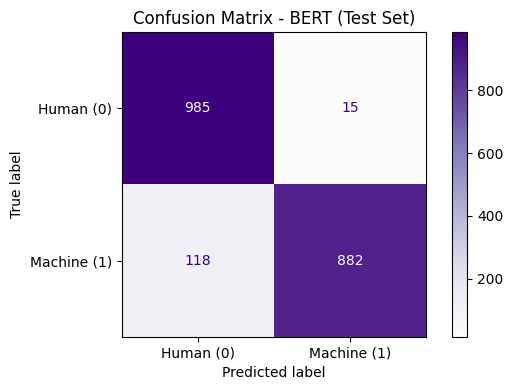

In [4]:
print("--- Final Evaluation on Test Set ---")

# Initialize a Trainer solely for prediction purposes
# We use a smaller batch size to avoid out-of-memory errors on local CPUs
eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=4, 
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args
)

# Predict on the test dataset
predictions_output = trainer.predict(tokenized_test)

# Extract predicted labels and true labels
y_pred_test = np.argmax(predictions_output.predictions, axis=1)
y_true_test = predictions_output.label_ids

# Print classification report
print("\n=== Classification Report - Neural Language Model ===")
print(classification_report(y_true_test, y_pred_test, digits=4))

# Plot Confusion Matrix
cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Human (0)", "Machine (1)"])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap="Purples", xticks_rotation=0)
plt.title("Confusion Matrix - BERT (Test Set)")
plt.tight_layout()
plt.show()